<a href="https://colab.research.google.com/github/daaim10/auto_encoders/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision matplotlib

In [ ]:
from torchvision import transforms

transform = transforms.ToTensor()
from torchvision.datasets import FashionMNIST
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
train_dataset = FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

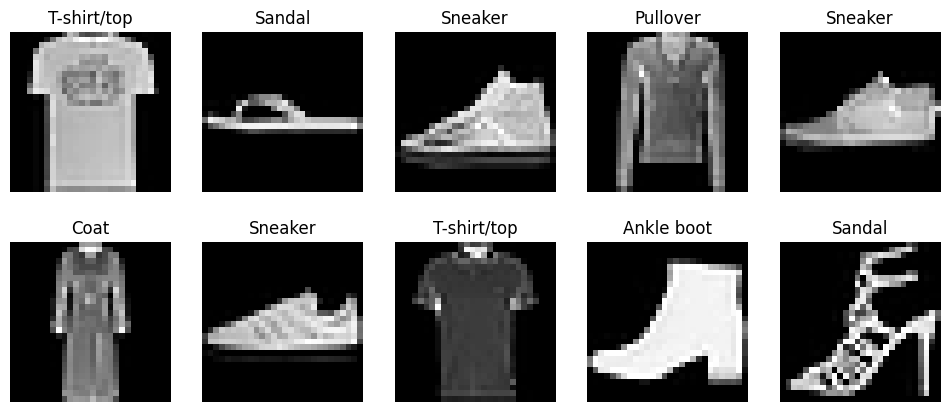

In [ ]:
classes = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784,512), #784 means the image which has 784 pixels. 512 means that this layer is gonna make 512 neurons. each neuron will take a look at all 512 values and then output one value. and this happens by every neuron hence the output of this layer is 512 values
            nn.ReLU(), #activation function which changes the negative values to 0
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128)
        )

        self.decoder = nn.Sequential(
            nn.Linear(128,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Sigmoid()
        )

    def forward(self,x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = Autoencoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.view(-1,784).to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss/len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss = {avg_loss:.6f}")

Epoch [1/10] Loss = 0.027820
Epoch [2/10] Loss = 0.016342
Epoch [3/10] Loss = 0.013747
Epoch [4/10] Loss = 0.012288
Epoch [5/10] Loss = 0.011297
Epoch [6/10] Loss = 0.010540
Epoch [7/10] Loss = 0.009989
Epoch [8/10] Loss = 0.009544
Epoch [9/10] Loss = 0.009152
Epoch [10/10] Loss = 0.008794


In [ ]:
images, _ = next(iter(test_loader))

sample = images[:8]

with torch.no_grad():

    reconstructed = model(
        sample.view(-1,784).to(device)
    )

sample = sample.cpu()
reconstructed = reconstructed.cpu()

sample = sample.view(-1,28,28)
reconstructed = reconstructed.view(-1,28,28)

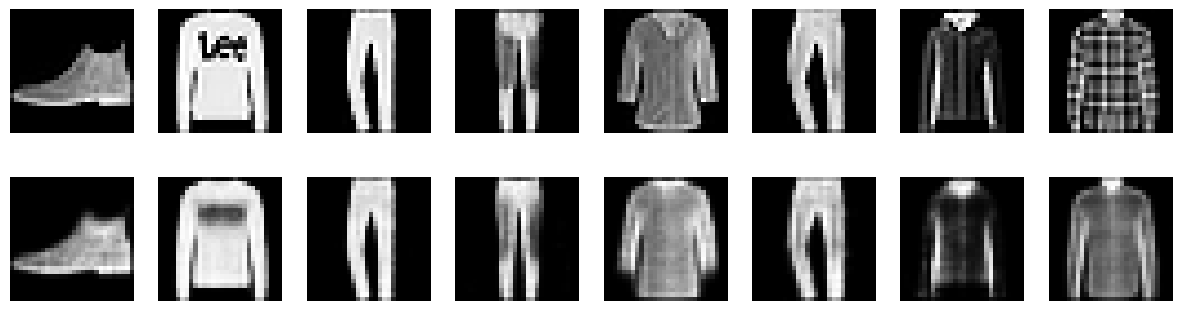

In [ ]:
fig, axes = plt.subplots(2,8, figsize=(15,4))

for i in range(8):

    axes[0,i].imshow(sample[i], cmap='gray')
    axes[0,i].axis('off')

    axes[1,i].imshow(reconstructed[i], cmap='gray')
    axes[1,i].axis('off')

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Reconstructed")

plt.show()